# Lorenz Homework #1 — Standalone + Frozen V2 verification

این نسخه **standalone** است: به ساختار پوشه‌ی GitHub، فایل `history/lorenz_homework.py` یا مسیر `protocols/...` وابسته نیست.

- بخش A: حل کامل تکلیف با Forward Euler برای `r=15` و `r=50` و هر دو شرط اولیه.
- بخش B: آزمون همگرایی کوتاه‌مدت Euler مطابق H1‑V2 frozen.
- بخش C: طیف کامل سه‌نمایی لیاپانوف با RK4 + QR مطابق H1‑V2 frozen.
- همه‌ی حلقه‌های طولانی `tqdm` دارند.
- خروجی‌ها در پوشه‌ی `H1_V2_results/` کنار محل اجرای نوت‌بوک ذخیره می‌شوند.
- `Run All` باید بدون نیاز به فایل خارجی اجرا شود.

> نکته: تنظیمات علمی V2 از پروتکل frozen مورخ 2026-10-05 گرفته شده‌اند و در این نوت‌بوک تغییر داده نشده‌اند.


In [1]:

from pathlib import Path
from datetime import datetime, timezone
import json, hashlib, time, platform, sys, os
import numpy as np
import scipy
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# -----------------------------
# Standalone paths
# -----------------------------
ROOT = Path.cwd()
OUT = ROOT / "H1_V2_results"
OUT.mkdir(parents=True, exist_ok=True)

RUN_ID = "H1-V2-STANDALONE-20261005"
STARTED = datetime.now(timezone.utc).isoformat()
CLOCK = time.monotonic()

# -----------------------------
# Frozen V2 protocol snapshot
# -----------------------------
FROZEN_PROTOCOL = '# H1-V2 — پروتکل همگرایی و لیاپانوف\nDate: 2026-10-05. Settings fixed and published before V2 execution. Historical H1 outcomes already exposed; this is a prospective numerical verification/diagnostic protocol, not an outcome-blind independent replication.\nOwner: moradi-am. Canonical repo: Homework. Source: uploaded H1.pdf, s=10,b=8/3,r=15/50, u0=(0,1,0)/(0,1.001,0).\nReuse: Research-OS EXP-2026-002 (trace ≠ detection), EXP-2026-008 (agreement ≠ convergence); prior Lorenz audit commits 13c5cde and e933ca1.\n## Tests\n### H1-V2-CONV\nHorizon t=[0,1], sample every .001; Euler steps [.001,.0005,.00025,.000125,.0000625,.00003125,.000015625], all 4 (r,u0) cases. All simultaneous Euler updates.\nReference DOP853 with rtol=1e-11,atol=1e-13,max_step=.01; tighter comparator rtol=1e-13,atol=1e-15,max_step=.005. This reference is numerical, not analytic exact truth.\nNormalize each component by fixed a priori [20,30,60].\nPrimary E(dt)=max over sampled times of Euclidean norm((Euler-reference)/scale).\nOrder p=log2(E(dt)/E(dt/2)). Reference discrepancy must be <1e-6 and <.01*smallest Euler E.\nFirst-order gate: all last 3 p values in [.85,1.15] and errors decrease at all refinements.\nAccuracy gate: smallest-step normalized E≤.001 (0.1% of stated vector scales in norm); report separately whether historical dt=.0001 meets same budget using a separate Euler evaluation, not interpolation.\nNo long-time pointwise convergence claim. If gate fails, retain FAIL and do not relax settings.\n### H1-V2-LYAP\nFull 3-exponent tangent spectrum via fixed-step RK4 state+tangent equations and QR renormalization. J=[[-10,10,0],[r-z,-1,-x],[y,x,-8/3]].\nTtotal=600, burn-in=100, accumulation=500; blocks=50; QR interval=.1.\nBase initial condition (0,1,0): dt [.01,.005,.0025] at both r.\nPerturbed (0,1.001,0): dt=.0025 at both r.\nQR-interval comparator .05: dt=.0025, base initial condition at both r.\nTotal 10 independent computational units (not independent physical replications). Initial tangent identity; no random seed. Sort final exponents descending for report; keep original QR diagonal history.\nExpected divergence sum = -(10+1+8/3)=-13.6666666667.\nNumerical gates: abs(sum-spectrum+13.6666666667)≤.01 every unit; base largest-exponent differences between finest two steps≤.15 and QR interval comparator≤.15 at both r.\nr15 analytic-control gate: sorted spectrum agrees with [-.35019310244,-.35019310244,-12.96628046178] to max absolute error≤.03 on all dt=.0025 units; largest exponent negative.\nr50 chaos-evidence gate: largest exponent >.1, middle exponent abs≤.1 on all units; largest-exponent difference base versus perturbed at dt=.0025≤.15; base finest mean of last100 and last200 accumulation versus full500 each within .15.\nThese are finite-horizon engineering diagnostic criteria, not statistical CIs or proof of asymptotic mathematical chaos. Positive finite-time exponent alone is insufficient without the numerical/control gates.\n### Delivery/reproducibility\nPreserve original H1 and historical .py/JSON/figures/ZIP as imported history, not rewritten preregistration. Complete notebook implements full homework plus V2 tests; REBUILD_HOMEWORK defaults false because original figures exist, and true regenerates required Euler full-time figures in a distinct output directory.\nFull V2 notebook run must succeed in a fresh kernel; checkpoints carry config/code hashes, shape/finite-value audits and atomic promotion; no invalid checkpoint silently reused. Runtime unit counters writer-owned with tqdm and heartbeat. Canonical compact evidence includes sampled convergence curves, QR log-stretch blocks, metrics, environment, hashes, progress and decision receipts.\n## Red-team\nK-H1-NUM: apparent chaos/order may be discretization artifact → reference convergence, Euler order and RK4 refinement gates.\nK-H1-LYAP: finite horizon/QR algorithm/transient may bias exponent → analytic stable control, trace sum, QR-interval/step/initial-condition/tail checks.\nK-H1-METRIC: ordinary norm or lobe switch is not effective metric/basin transition → no such promotion.\nK-H1-PROVENANCE: historical intermediate versions/trajectories incomplete → preserve limitation; V2 hashes/archives separately.\nFreeze verdict: freeze-allowed-with-open-killers; future failure remains failure. No retuning after V2 outcome. Debugging syntax/I/O only may preserve exact semantics and must be logged.\n## Boundary\nNo DNS/turbulence transfer, no novel metric, no event prediction. No downloaded textbook or external literature is needed to verify the supplied ODE; solver is an implementation tool.\n'
PROTOCOL_HASH = hashlib.sha256(FROZEN_PROTOCOL.encode("utf-8")).hexdigest()
(OUT / "H1_V2_frozen_snapshot.md").write_text(FROZEN_PROTOCOL, encoding="utf-8")

CFG = {
    "r": [15, 50],
    "y0": [1.0, 1.001],
    "scale": [20.0, 30.0, 60.0],
    "conv_T": 1.0,
    "sample_dt": 0.001,
    "euler_steps": [0.001, 0.0005, 0.00025, 0.000125, 0.0000625, 0.00003125, 0.000015625],
    "reference": [1e-11, 1e-13, 0.01],
    "reference_tight": [1e-13, 1e-15, 0.005],
    "lyap_T": 600.0,
    "burn": 100.0,
    "block": 50.0,
    "qr": 0.1,
    "rk_steps": [0.01, 0.005, 0.0025],
    "gates": {
        "order": [0.85, 1.15],
        "accuracy": 0.001,
        "reference_abs": 1e-6,
        "reference_frac": 0.01,
        "trace": 0.01,
        "lyap_refinement": 0.15,
        "r15_analytic": 0.03,
        "r50_positive": 0.1,
        "r50_zero": 0.1,
        "lyap_tail": 0.15
    }
}

CONFIG_HASH = hashlib.sha256(
    json.dumps(CFG, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

# Homework-only settings (not V2 gates)
HOMEWORK_DT = 0.001
HOMEWORK_T = 1000.0
HOMEWORK_SAVE_DT = 0.01

def atomic_json(path, obj):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, allow_nan=False), encoding="utf-8")
    json.loads(tmp.read_text(encoding="utf-8"))
    os.replace(tmp, path)

def progress_receipt(phase, done, total, unit):
    atomic_json(OUT / "runtime_progress.json", {
        "run_id": RUN_ID,
        "status": "RUNNING",
        "phase": phase,
        "completed_units": int(done),
        "total_units": int(total),
        "progress_unit": unit,
        "started_at": STARTED,
        "updated_at": datetime.now(timezone.utc).isoformat(),
        "elapsed_seconds": float(time.monotonic() - CLOCK),
        "protocol_hash": PROTOCOL_HASH,
        "config_hash": CONFIG_HASH
    })

print("Output directory:", OUT.resolve())
print("Protocol SHA256:", PROTOCOL_HASH)
print("Config SHA256:", CONFIG_HASH)


Output directory: /home/hatch/workspace/homework/H1_Lorenz_V3_ORIG/H1_V2_results
Protocol SHA256: 7b460b9f5e230bab1ff5bedc0ff3f0fbf98492e6a04148e7c2334ec91c6db36c
Config SHA256: f10c98d7972106cd413b3a47cccc8d26f2d45feaeb2ed3a5e25d939980860a74


/home/hatch/workspace/homework/H1_Lorenz_V3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# -----------------------------
# Lorenz model + integrators
# -----------------------------
SIGMA = 10.0
BETA = 8.0 / 3.0

def rhs(u, r):
    x, y, z = u
    return np.array([
        SIGMA * (y - x),
        r * x - x * z - y,
        x * y - BETA * z
    ], dtype=float)

def euler_trajectory(r, y0, T, dt, save_dt=None, desc="Euler"):
    """
    Forward Euler with simultaneous component update.
    If save_dt is given, only regularly sampled states are retained.
    """
    n = int(round(T / dt))
    if save_dt is None:
        stride = 1
        save_dt = dt
    else:
        stride = int(round(save_dt / dt))
        if not np.isclose(stride * dt, save_dt, rtol=0, atol=1e-14):
            raise ValueError("save_dt must be an integer multiple of dt")

    nsaved = n // stride + 1
    t = np.empty(nsaved, dtype=float)
    X = np.empty((nsaved, 3), dtype=float)

    u = np.array([0.0, float(y0), 0.0], dtype=float)
    t[0] = 0.0
    X[0] = u
    j = 1

    for i in tqdm(range(1, n + 1), desc=desc, leave=False):
        u = u + dt * rhs(u, r)
        if i % stride == 0:
            t[j] = i * dt
            X[j] = u
            j += 1

    if not np.all(np.isfinite(X)):
        raise FloatingPointError(f"Non-finite Euler state for r={r}, y0={y0}, dt={dt}")
    return t, X

def euler_sample_v2(r, y0, dt):
    t, X = euler_trajectory(
        r=r, y0=y0, T=CFG["conv_T"], dt=dt,
        save_dt=CFG["sample_dt"],
        desc=f"V2 Euler r={r}, y0={y0:g}, dt={dt:g}"
    )
    if X.shape != (1001, 3):
        raise RuntimeError(f"Unexpected sampled shape: {X.shape}")
    return t, X

def augmented_rhs(u, V, r):
    x, y, z = u
    J = np.array([
        [-10.0, 10.0, 0.0],
        [r - z, -1.0, -x],
        [y, x, -8.0/3.0]
    ])
    return rhs(u, r), J @ V

def rk4_state_tangent(u, V, r, h):
    a, A = augmented_rhs(u, V, r)
    b, B = augmented_rhs(u + 0.5*h*a, V + 0.5*h*A, r)
    c, C = augmented_rhs(u + 0.5*h*b, V + 0.5*h*B, r)
    d, D = augmented_rhs(u + h*c, V + h*C, r)
    un = u + (h/6.0)*(a + 2*b + 2*c + d)
    Vn = V + (h/6.0)*(A + 2*B + 2*C + D)
    return un, Vn

# Tiny smoke test before expensive work
_u = np.array([0.0, 1.0, 0.0])
_test = _u + 1e-3 * rhs(_u, 15)
assert np.all(np.isfinite(_test)) and _test.shape == (3,)
print("Core numerical functions: OK")


Core numerical functions: OK


Homework cases:   0%|          | 0/4 [00:00<?, ?it/s]

Homework r=15, y0=1:   0%|          | 0/1000000 [00:00<?, ?it/s]

Homework r=15, y0=1:   2%|▏         | 20162/1000000 [00:00<00:04, 201592.80it/s]

Homework r=15, y0=1:   4%|▍         | 40322/1000000 [00:00<00:05, 186609.18it/s]

Homework r=15, y0=1:   6%|▌         | 61273/1000000 [00:00<00:04, 196624.56it/s]

...

Homework r=50, y0=1.001:  96%|█████████▌| 959632/1000000 [00:04<00:00, 212414.58it/s]

Homework r=50, y0=1.001:  98%|█████████▊| 982247/1000000 [00:04<00:00, 216475.91it/s]

Homework cases: 100%|██████████| 4/4 [00:19<00:00,  4.81s/it]

Homework cases: 100%|██████████| 4/4 [00:19<00:00,  4.80s/it]

r=15, y0=1: tail center = [-6.11010093 -6.11010093 14.        ], RMS radius = 2.94657e-12
r=15, y0=1.001: tail center = [-6.11010093 -6.11010093 14.        ], RMS radius = 2.94657e-12


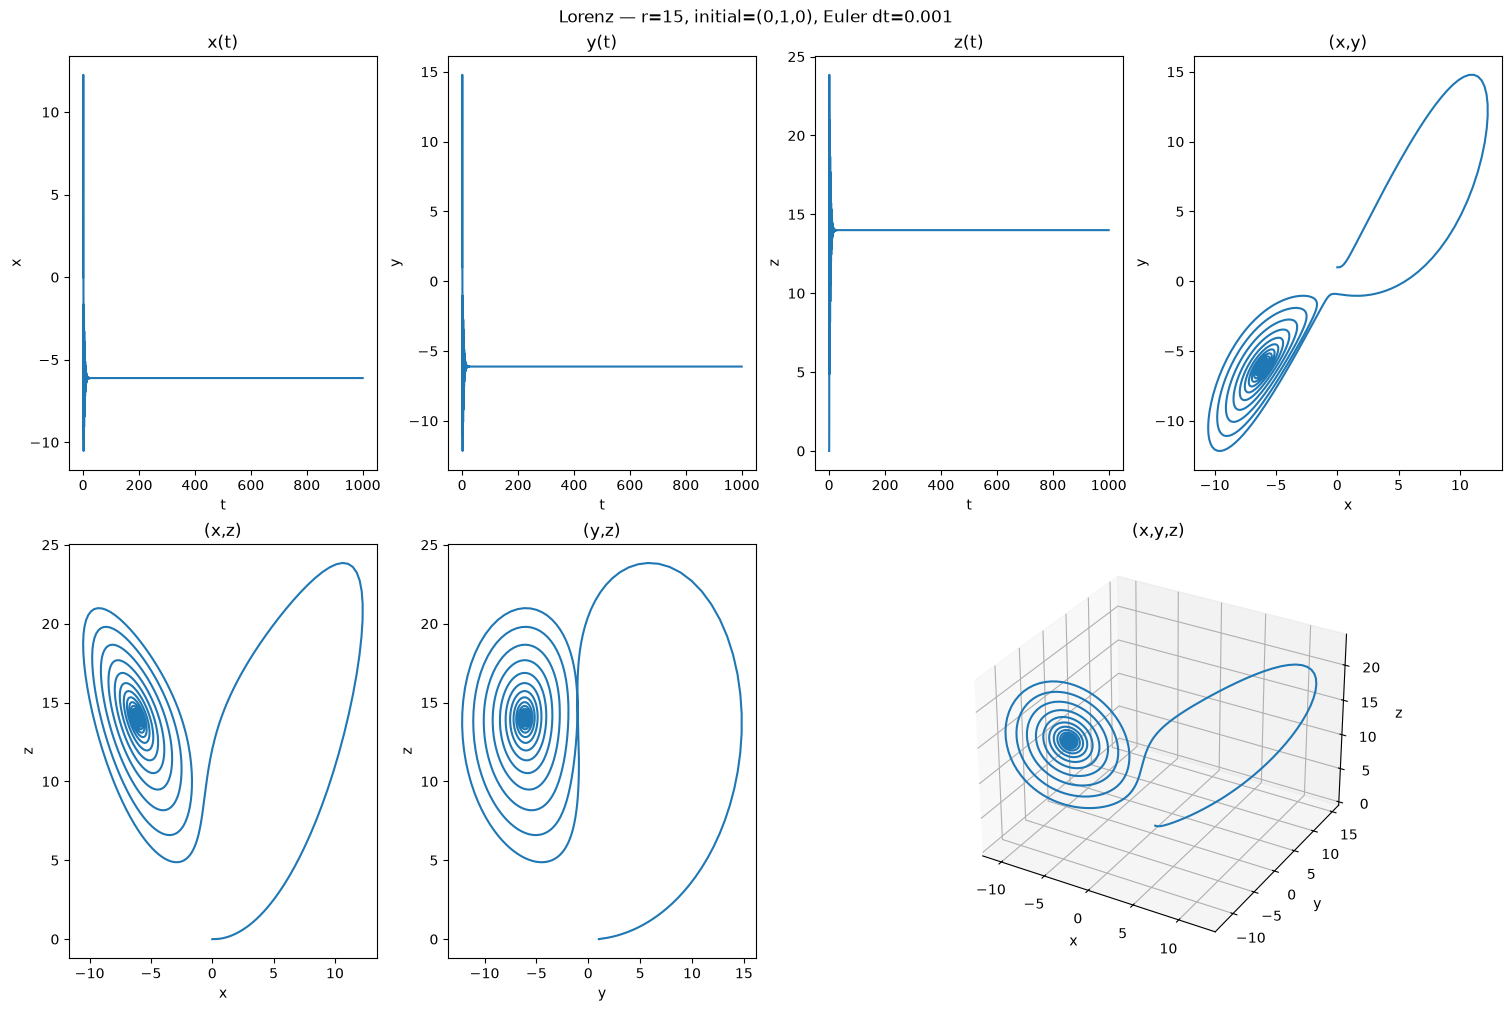

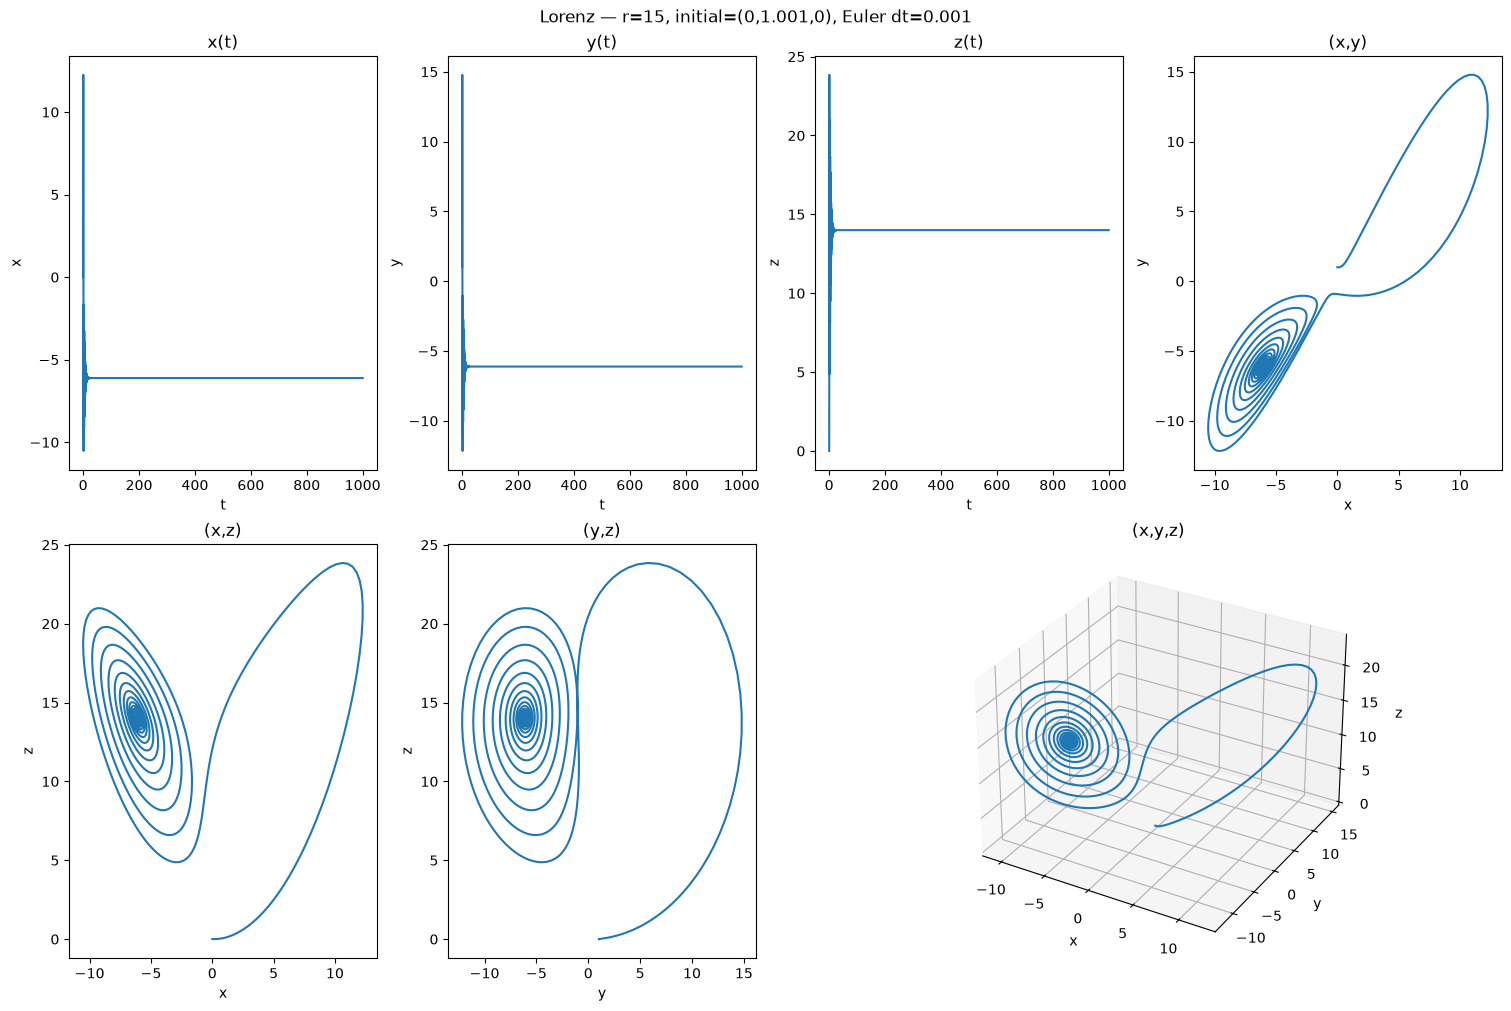

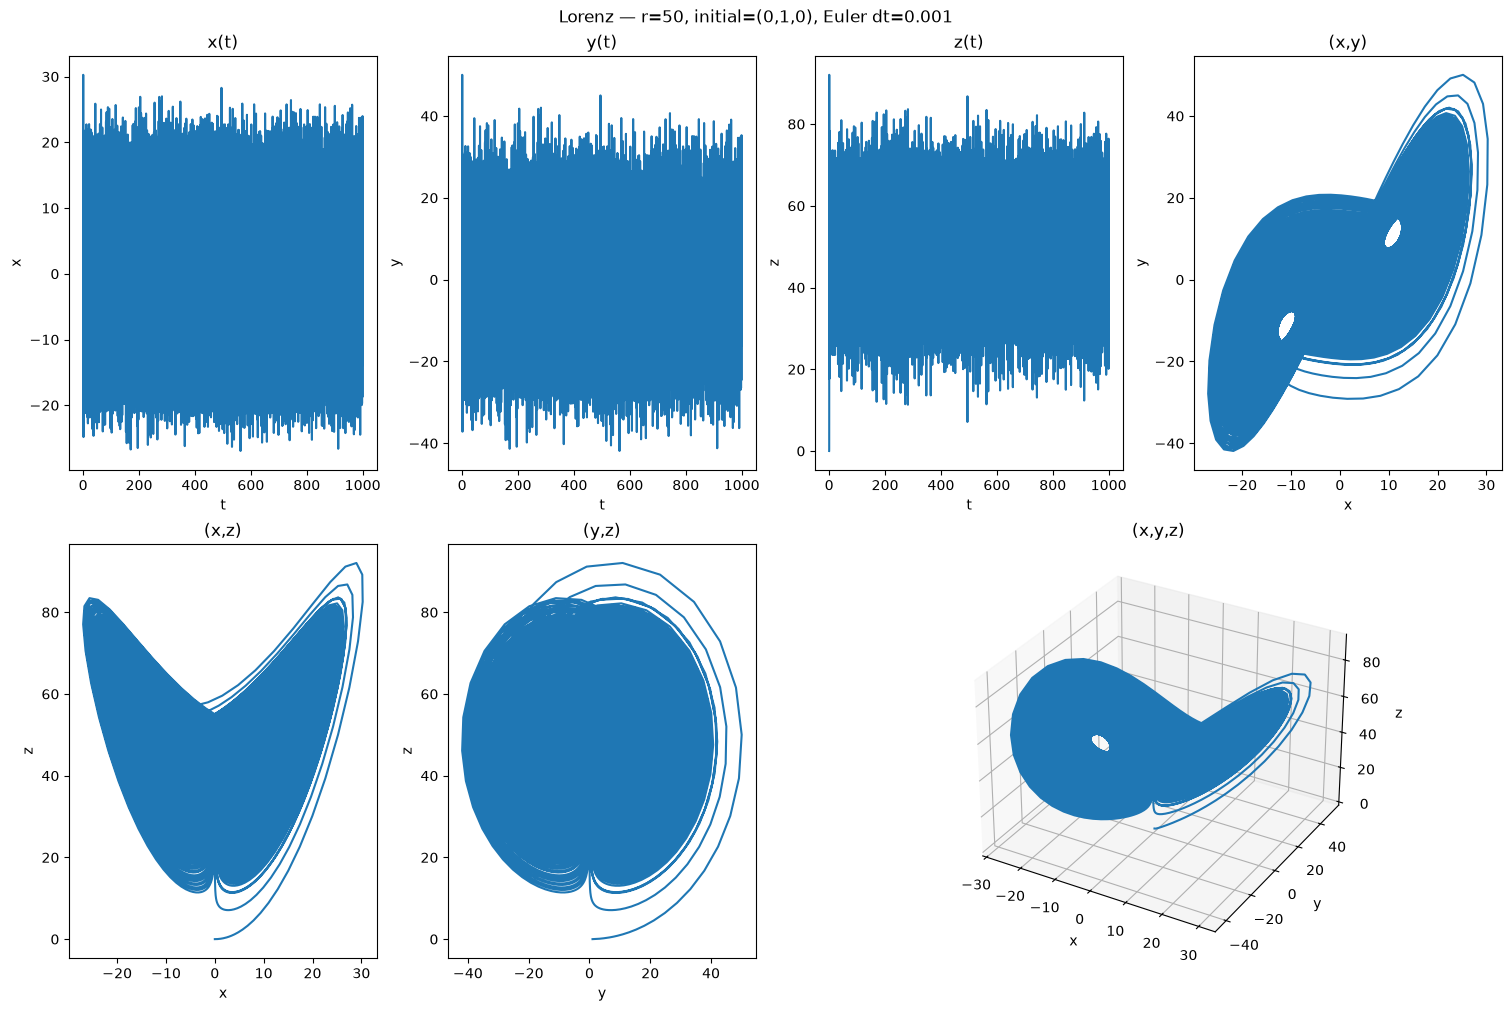

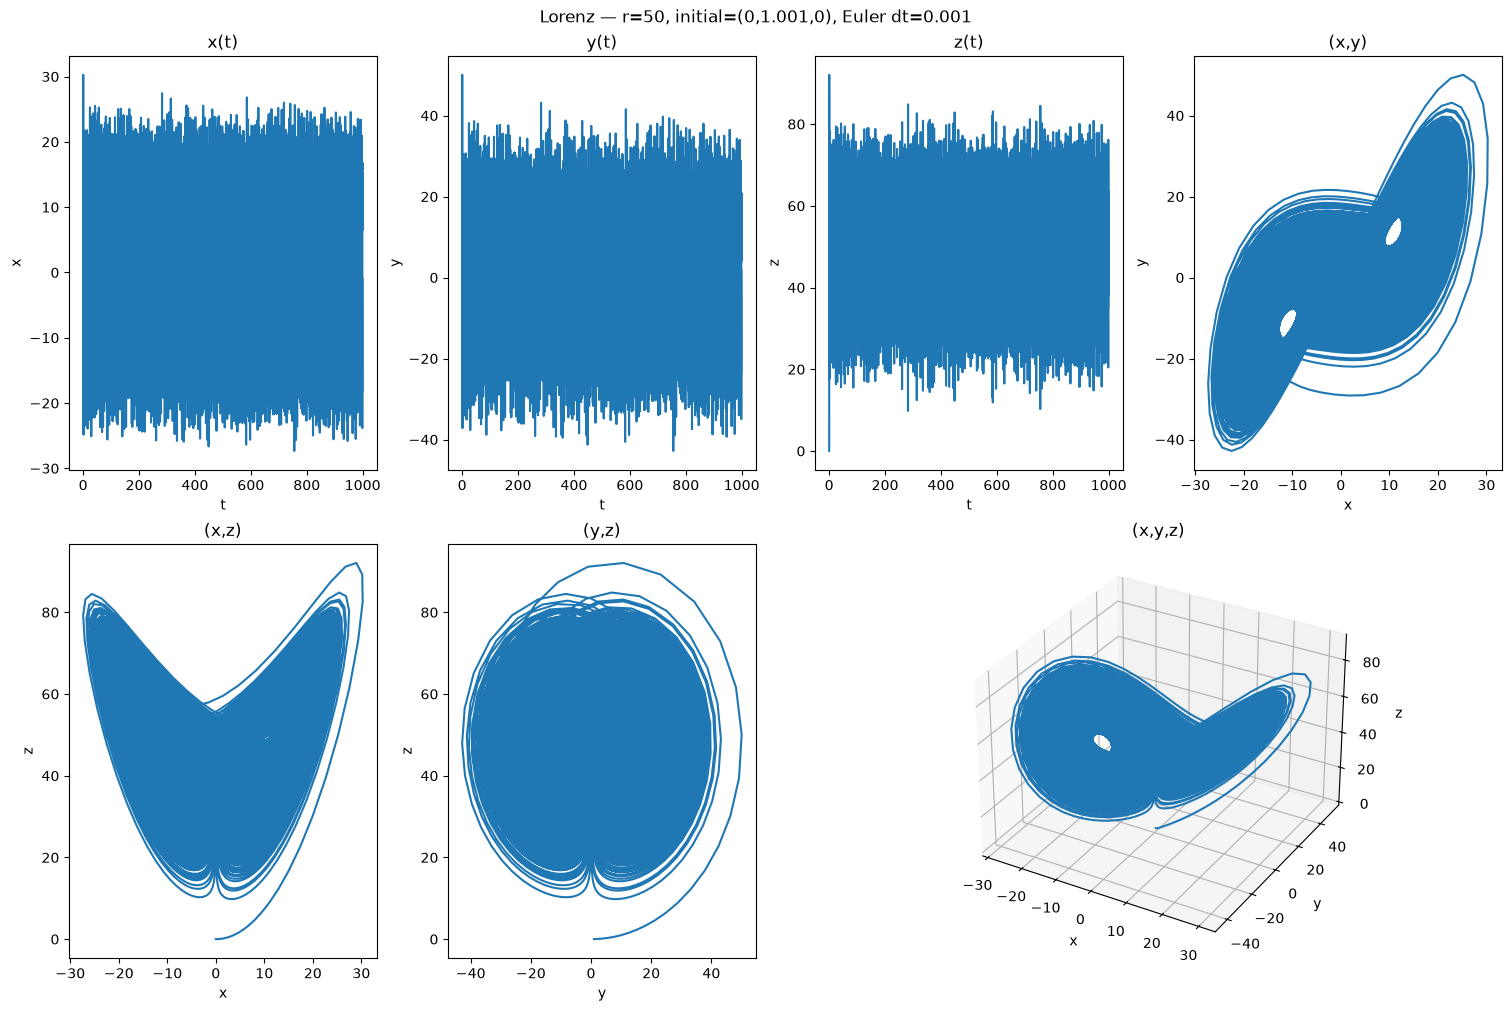

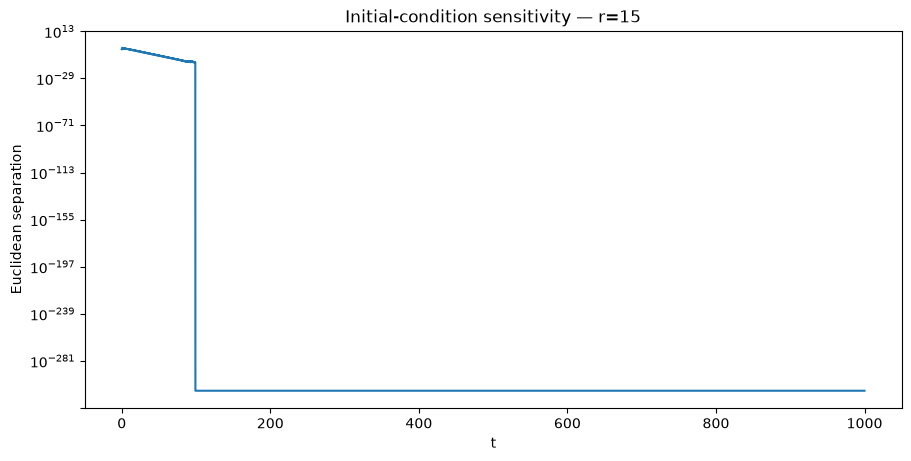

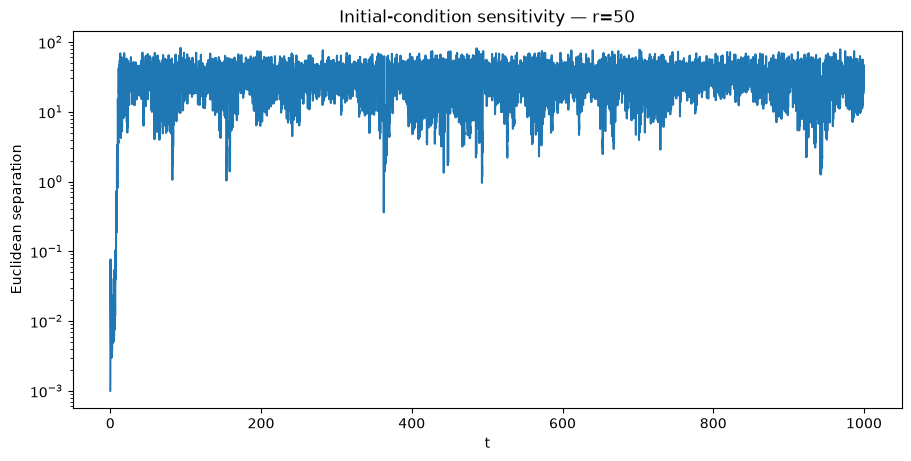

Homework section complete.


In [3]:

# ============================================================
# A) FULL HOMEWORK — Forward Euler, t in [0,1000]
# ============================================================
HOMEWORK = {}

cases = [(15, 1.0), (15, 1.001), (50, 1.0), (50, 1.001)]
for ci, (r, y0) in enumerate(tqdm(cases, desc="Homework cases")):
    t, X = euler_trajectory(
        r=r, y0=y0, T=HOMEWORK_T, dt=HOMEWORK_DT,
        save_dt=HOMEWORK_SAVE_DT,
        desc=f"Homework r={r}, y0={y0:g}"
    )
    HOMEWORK[(r, y0)] = {"t": t, "X": X}
    np.savez_compressed(OUT / f"homework_r{r}_y{y0:g}.npz", t=t, X=X)
    progress_receipt("homework", ci + 1, len(cases), "case")

# Periodic/attractor center estimate requested by the assignment:
# use the mean of the final 20% of the saved trajectory.
for y0 in [1.0, 1.001]:
    dat = HOMEWORK[(15, y0)]
    X = dat["X"]
    tail = X[int(0.8 * len(X)):]
    center = tail.mean(axis=0)
    radius_rms = np.sqrt(np.mean(np.sum((tail - center)**2, axis=1)))
    print(f"r=15, y0={y0:g}: tail center = {center}, RMS radius = {radius_rms:.6g}")

def plot_case(r, y0):
    dat = HOMEWORK[(r, y0)]
    t, X = dat["t"], dat["X"]
    x, y, z = X.T

    fig = plt.figure(figsize=(15, 10), constrained_layout=True)
    gs = fig.add_gridspec(2, 4)

    ax = fig.add_subplot(gs[0, 0])
    ax.plot(t, x); ax.set(title="x(t)", xlabel="t", ylabel="x")

    ax = fig.add_subplot(gs[0, 1])
    ax.plot(t, y); ax.set(title="y(t)", xlabel="t", ylabel="y")

    ax = fig.add_subplot(gs[0, 2])
    ax.plot(t, z); ax.set(title="z(t)", xlabel="t", ylabel="z")

    ax = fig.add_subplot(gs[0, 3])
    ax.plot(x, y); ax.set(title="(x,y)", xlabel="x", ylabel="y")

    ax = fig.add_subplot(gs[1, 0])
    ax.plot(x, z); ax.set(title="(x,z)", xlabel="x", ylabel="z")

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(y, z); ax.set(title="(y,z)", xlabel="y", ylabel="z")

    ax3 = fig.add_subplot(gs[1, 2:], projection="3d")
    ax3.plot(x, y, z)
    ax3.set(title="(x,y,z)", xlabel="x", ylabel="y", zlabel="z")

    fig.suptitle(f"Lorenz — r={r}, initial=(0,{y0:g},0), Euler dt={HOMEWORK_DT:g}")
    fig.savefig(OUT / f"homework_r{r}_y{y0:g}.png", dpi=170)
    plt.show()

for r, y0 in cases:
    plot_case(r, y0)

# Direct sensitivity comparison between initial conditions
for r in [15, 50]:
    A = HOMEWORK[(r, 1.0)]["X"]
    B = HOMEWORK[(r, 1.001)]["X"]
    t = HOMEWORK[(r, 1.0)]["t"]
    d = np.linalg.norm(B - A, axis=1)

    plt.figure(figsize=(9, 4.5), constrained_layout=True)
    plt.semilogy(t, np.maximum(d, np.finfo(float).tiny))
    plt.xlabel("t")
    plt.ylabel("Euclidean separation")
    plt.title(f"Initial-condition sensitivity — r={r}")
    plt.savefig(OUT / f"sensitivity_r{r}.png", dpi=170)
    plt.show()

print("Homework section complete.")


V2 convergence cases:   0%|          | 0/4 [00:00<?, ?it/s]

V2 Euler r=15, y0=1, dt=0.001:   0%|          | 0/1000 [00:00<?, ?it/s]

V2 Euler r=15, y0=1, dt=0.0005:   0%|          | 0/2000 [00:00<?, ?it/s]

V2 Euler r=15, y0=1, dt=0.00025:   0%|          | 0/4000 [00:00<?, ?it/s]

V2 Euler r=15, y0=1, dt=0.000125:   0%|          | 0/8000 [00:00<?, ?it/s]

...

V2 Euler r=50, y0=1.001, dt=1.5625e-05:  32%|███▏      | 20693/64000 [00:00<00:00, 206917.86it/s]

V2 Euler r=50, y0=1.001, dt=1.5625e-05:  68%|██████▊   | 43205/64000 [00:00<00:00, 217617.54it/s]

V2 Euler r=50, y0=1.001, dt=0.0001:   0%|          | 0/10000 [00:00<?, ?it/s]

V2 convergence cases: 100%|██████████| 4/4 [00:03<00:00,  1.19it/s]

V2 convergence cases: 100%|██████████| 4/4 [00:03<00:00,  1.20it/s]

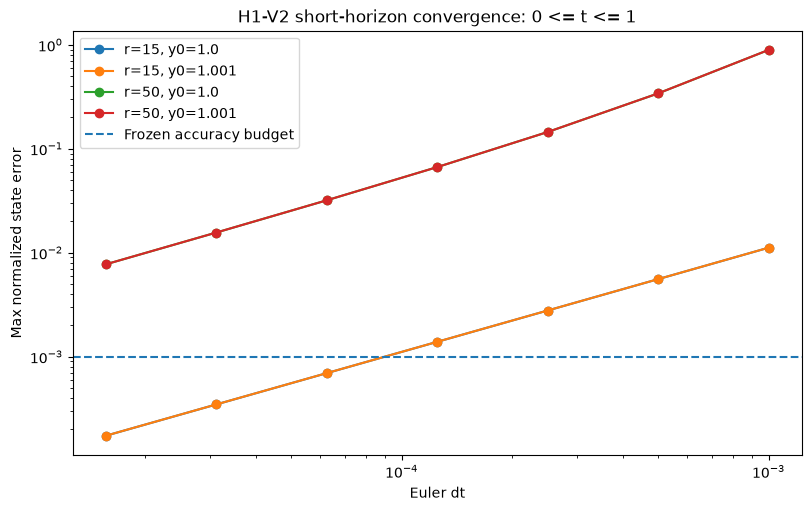

r=15, y0=1.0: PASS | E_finest=0.000173452 | p_last3=[1.00059402 1.0002979  1.00014917]
r=15, y0=1.001: PASS | E_finest=0.000173522 | p_last3=[1.00059359 1.00029769 1.00014907]
r=50, y0=1.0: FAIL | E_finest=0.00773331 | p_last3=[1.06102204 1.03054273 1.01527087]
r=50, y0=1.001: FAIL | E_finest=0.00773353 | p_last3=[1.06105875 1.03056033 1.01527947]


In [4]:

# ============================================================
# B) H1-V2-CONV — frozen short-horizon convergence test
# ============================================================
CONV = []
ts = np.arange(1001, dtype=float) * CFG["sample_dt"]
scale = np.array(CFG["scale"], dtype=float)

for ci, (r, y0) in enumerate(tqdm(cases, desc="V2 convergence cases")):
    refs = []
    for tol in [CFG["reference"], CFG["reference_tight"]]:
        sol = solve_ivp(
            lambda t, u: rhs(u, r),
            (0.0, CFG["conv_T"]),
            [0.0, y0, 0.0],
            method="DOP853",
            t_eval=ts,
            rtol=tol[0],
            atol=tol[1],
            max_step=tol[2]
        )
        if not sol.success or sol.y.shape != (3, 1001):
            raise RuntimeError(f"DOP853 reference failed: r={r}, y0={y0}")
        refs.append(sol.y.T)

    eulers = []
    for h in CFG["euler_steps"]:
        _, Xh = euler_sample_v2(r, y0, h)
        eulers.append(Xh)
    eulers = np.stack(eulers)

    # Required historical dt=0.0001 is evaluated directly, not interpolated.
    _, historical = euler_sample_v2(r, y0, 0.0001)

    errors = np.max(
        np.linalg.norm((eulers - refs[1][None, :, :]) / scale, axis=2),
        axis=1
    )
    orders = np.log2(errors[:-1] / errors[1:])
    reference_discrepancy = float(
        np.max(np.linalg.norm((refs[0] - refs[1]) / scale, axis=1))
    )
    historical_error = float(
        np.max(np.linalg.norm((historical - refs[1]) / scale, axis=1))
    )

    gates = {
        "reference": bool(reference_discrepancy < min(
            CFG["gates"]["reference_abs"],
            CFG["gates"]["reference_frac"] * errors[-1]
        )),
        "decreasing": bool(np.all(np.diff(errors) < 0.0)),
        "order": bool(np.all(
            (orders[-3:] >= CFG["gates"]["order"][0]) &
            (orders[-3:] <= CFG["gates"]["order"][1])
        )),
        "accuracy_finest": bool(errors[-1] <= CFG["gates"]["accuracy"])
    }

    result = {
        "r": r,
        "y0": y0,
        "steps": CFG["euler_steps"],
        "errors": errors.tolist(),
        "orders": orders.tolist(),
        "reference_discrepancy": reference_discrepancy,
        "historical_dt_0001_error": historical_error,
        "historical_dt_0001_accuracy_pass": bool(historical_error <= CFG["gates"]["accuracy"]),
        "gates": gates,
        "verdict": "PASS" if all(gates.values()) else "FAIL"
    }
    CONV.append(result)
    progress_receipt("convergence", ci + 1, len(cases), "case")

atomic_json(OUT / "convergence.json", CONV)

plt.figure(figsize=(8, 5), constrained_layout=True)
for c in CONV:
    plt.loglog(c["steps"], c["errors"], "o-", label=f'r={c["r"]}, y0={c["y0"]}')
plt.axhline(CFG["gates"]["accuracy"], linestyle="--", label="Frozen accuracy budget")
plt.xlabel("Euler dt")
plt.ylabel("Max normalized state error")
plt.title("H1-V2 short-horizon convergence: 0 <= t <= 1")
plt.legend()
plt.savefig(OUT / "convergence.png", dpi=170)
plt.show()

for c in CONV:
    print(
        f'r={c["r"]}, y0={c["y0"]}: {c["verdict"]} | '
        f'E_finest={c["errors"][-1]:.6g} | '
        f'p_last3={np.array(c["orders"][-3:])}'
    )


Lyapunov units:   0%|          | 0/10 [00:00<?, ?it/s]

r=15, y0=1, dt=0.01, qr=0.1:   0%|          | 0/6000 [00:00<?, ?it/s]

r=15, y0=1, dt=0.01, qr=0.1:   3%|▎         | 164/6000 [00:00<00:03, 1631.64it/s]

r=15, y0=1, dt=0.01, qr=0.1:   6%|▌         | 346/6000 [00:00<00:03, 1741.95it/s]

r=15, y0=1, dt=0.01, qr=0.1:   9%|▊         | 521/6000 [00:00<00:03, 1694.92it/s]

...

r=50, y0=1, dt=0.0025, qr=0.05:  98%|█████████▊| 11817/12000 [00:13<00:00, 900.00it/s]

r=50, y0=1, dt=0.0025, qr=0.05:  99%|█████████▉| 11908/12000 [00:13<00:00, 892.67it/s]

r=50, y0=1, dt=0.0025, qr=0.05: 100%|█████████▉| 11998/12000 [00:13<00:00, 894.17it/s]

Lyapunov units: 100%|██████████| 10/10 [01:42<00:00, 12.48s/it]

Lyapunov units: 100%|██████████| 10/10 [01:42<00:00, 10.28s/it]

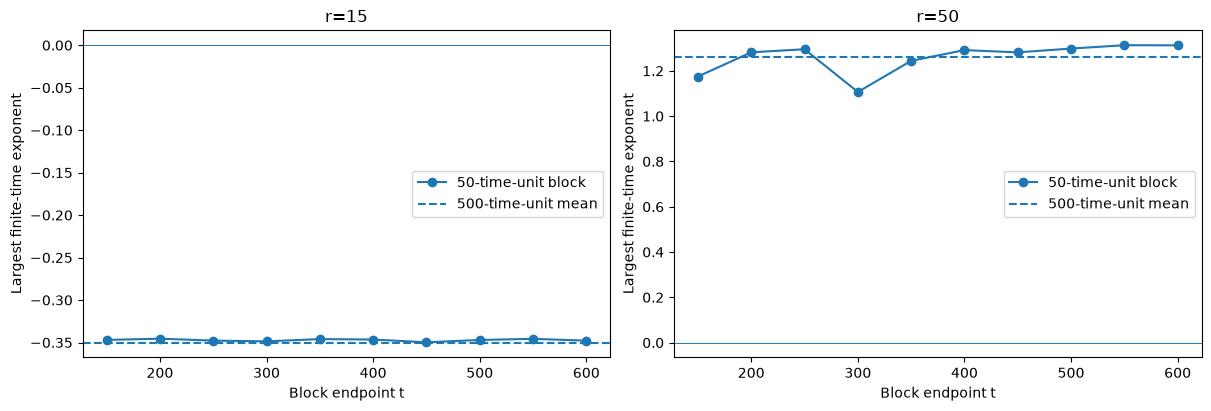

{
  "run_id": "H1-V2-STANDALONE-20261005",
  "gates": {
    "convergence_all": false,
    "trace_all": true,
    "r15_dt": true,
    "r15_qr": true,
    "r15_analytic": true,
    "r50_dt": true,
    "r50_qr": true,
    "r50_positive_zero": true,
    "r50_initial_condition": true,
    "r50_tail": true
  },
  "overall": "NOT_ALL_GATES_PASS",
  "limits": [
    "Finite-horizon numerical evidence, not a proof of asymptotic chaos",
    "No transition-distance or turbulence transfer",
    "Frozen V2 numerical/diagnostic scope only"
  ],
  "config_hash": "f10c98d7972106cd413b3a47cccc8d26f2d45feaeb2ed3a5e25d939980860a74",
  "protocol_hash": "7b460b9f5e230bab1ff5bedc0ff3f0fbf98492e6a04148e7c2334ec91c6db36c"
}


In [5]:

# ============================================================
# C) H1-V2-LYAP — full 3-exponent RK4 + QR spectrum
# ============================================================
UNITS = [(r, 1.0, h, 0.1) for r in [15, 50] for h in [0.01, 0.005, 0.0025]]
UNITS += [(r, 1.001, 0.0025, 0.1) for r in [15, 50]]
UNITS += [(r, 1.0, 0.0025, 0.05) for r in [15, 50]]

LYAP = []

for ui, (r, y0, h, qr) in enumerate(tqdm(UNITS, desc="Lyapunov units")):
    intervals = int(round(CFG["lyap_T"] / qr))
    substeps = int(round(qr / h))
    if not np.isclose(substeps * h, qr, rtol=0, atol=1e-14):
        raise ValueError(f"QR interval {qr} is not divisible by dt {h}")

    u = np.array([0.0, y0, 0.0], dtype=float)
    V = np.eye(3)
    logs = np.empty((intervals, 3), dtype=float)
    times = np.arange(1, intervals + 1, dtype=float) * qr

    for k in tqdm(
        range(intervals),
        desc=f"r={r}, y0={y0:g}, dt={h:g}, qr={qr:g}",
        leave=False
    ):
        for _ in range(substeps):
            u, V = rk4_state_tangent(u, V, r, h)

        Q, R = np.linalg.qr(V)
        diag = np.diag(R)
        if np.any(np.abs(diag) == 0.0):
            raise FloatingPointError("Zero QR diagonal encountered")

        signs = np.where(diag >= 0.0, 1.0, -1.0)
        V = Q * signs[None, :]
        logs[k] = np.log(np.abs(diag))

    if not np.all(np.isfinite(logs)):
        raise FloatingPointError(f"Non-finite Lyapunov log stretch for r={r}")

    mask = times > CFG["burn"] + 1e-8
    L = logs[mask]
    tacc = times[mask]

    spectrum = np.sort(L.sum(axis=0) / 500.0)[::-1]

    blocks = []
    for bi in range(10):
        lo = 100.0 + bi * 50.0
        hi = lo + 50.0
        bm = (tacc > lo + 1e-8) & (tacc <= hi + 1e-8)
        blocks.append(np.sort(L[bm].sum(axis=0) / 50.0)[::-1].tolist())

    tail100 = np.sort(L[tacc > 500.0 + 1e-8].sum(axis=0) / 100.0)[::-1]
    tail200 = np.sort(L[tacc > 400.0 + 1e-8].sum(axis=0) / 200.0)[::-1]

    result = {
        "r": r,
        "y0": y0,
        "dt": h,
        "qr": qr,
        "spectrum": spectrum.tolist(),
        "blocks50": blocks,
        "tail100": tail100.tolist(),
        "tail200": tail200.tolist(),
        "trace_error": float(abs(spectrum.sum() + 13.666666666666666))
    }
    LYAP.append(result)

    np.savez_compressed(
        OUT / f"lyap_r{r}_y{y0:g}_dt{h:g}_qr{qr:g}.npz",
        t=times, logs=logs
    )
    progress_receipt("lyapunov", ui + 1, len(UNITS), "integration_unit")

atomic_json(OUT / "lyapunov.json", LYAP)

def lookup(r, y0, h, qr):
    for a in LYAP:
        if (a["r"], a["y0"], a["dt"], a["qr"]) == (r, y0, h, qr):
            return a
    raise KeyError((r, y0, h, qr))

GATES = {
    "convergence_all": all(c["verdict"] == "PASS" for c in CONV),
    "trace_all": all(a["trace_error"] <= CFG["gates"]["trace"] for a in LYAP)
}

for r in [15, 50]:
    a = lookup(r, 1.0, 0.0025, 0.1)
    b = lookup(r, 1.0, 0.005, 0.1)
    q = lookup(r, 1.0, 0.0025, 0.05)
    p = lookup(r, 1.001, 0.0025, 0.1)

    GATES[f"r{r}_dt"] = abs(a["spectrum"][0] - b["spectrum"][0]) <= CFG["gates"]["lyap_refinement"]
    GATES[f"r{r}_qr"] = abs(a["spectrum"][0] - q["spectrum"][0]) <= CFG["gates"]["lyap_refinement"]

    if r == 15:
        expected = np.array([
            -0.35019310244287927,
            -0.35019310244287927,
            -12.966280461780894
        ])
        GATES["r15_analytic"] = all(
            np.max(np.abs(np.array(x["spectrum"]) - expected)) <= CFG["gates"]["r15_analytic"]
            and x["spectrum"][0] < 0.0
            for x in LYAP if x["r"] == 15 and x["dt"] == 0.0025
        )
    else:
        GATES["r50_positive_zero"] = all(
            x["spectrum"][0] > CFG["gates"]["r50_positive"]
            and abs(x["spectrum"][1]) <= CFG["gates"]["r50_zero"]
            for x in LYAP if x["r"] == 50
        )
        GATES["r50_initial_condition"] = (
            abs(a["spectrum"][0] - p["spectrum"][0]) <= CFG["gates"]["lyap_refinement"]
        )
        GATES["r50_tail"] = (
            max(abs(a["spectrum"][0] - a[k][0]) for k in ["tail100", "tail200"])
            <= CFG["gates"]["lyap_tail"]
        )

DECISION = {
    "run_id": RUN_ID,
    "gates": GATES,
    "overall": "PASS_WITHIN_FROZEN_SCOPE" if all(GATES.values()) else "NOT_ALL_GATES_PASS",
    "limits": [
        "Finite-horizon numerical evidence, not a proof of asymptotic chaos",
        "No transition-distance or turbulence transfer",
        "Frozen V2 numerical/diagnostic scope only"
    ],
    "config_hash": CONFIG_HASH,
    "protocol_hash": PROTOCOL_HASH
}
atomic_json(OUT / "decision.json", DECISION)

# Diagnostic plot of largest finite-time exponent blocks
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, r in zip(axes, [15, 50]):
    a = lookup(r, 1.0, 0.0025, 0.1)
    endpoints = np.arange(10) * 50.0 + 150.0
    ax.plot(endpoints, np.array(a["blocks50"])[:, 0], "o-", label="50-time-unit block")
    ax.axhline(a["spectrum"][0], linestyle="--", label="500-time-unit mean")
    ax.axhline(0.0, linewidth=0.7)
    ax.set(
        xlabel="Block endpoint t",
        ylabel="Largest finite-time exponent",
        title=f"r={r}"
    )
    ax.legend()
fig.savefig(OUT / "lyapunov.png", dpi=170)
plt.show()

# Environment + final receipts
atomic_json(OUT / "environment.json", {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "config": CFG
})

atomic_json(OUT / "runtime_progress.json", {
    "run_id": RUN_ID,
    "status": "COMPLETE",
    "phase": "all",
    "completed_units": int(len(cases) + len(cases) + len(UNITS)),
    "total_units": int(len(cases) + len(cases) + len(UNITS)),
    "finished_at": datetime.now(timezone.utc).isoformat(),
    "protocol_hash": PROTOCOL_HASH,
    "config_hash": CONFIG_HASH
})

print(json.dumps(DECISION, indent=2))


## تفسیر خروجی

- `PASS_WITHIN_FROZEN_SCOPE` فقط یعنی معیارهای عددی از پیش‌ثبت‌شده‌ی H1‑V2 در همین دامنه پاس شده‌اند.
- برای `r=15`، کنترل تحلیلی طیف لیاپانوف و منفی بودن نمای بزرگ‌تر بررسی می‌شود.
- برای `r=50`، شواهد آشوب با نمای بزرگ‌تر مثبت، نمای میانی نزدیک صفر، کنترل گام، فاصله QR، شرط اولیه و tail بررسی می‌شود.
- این نتیجه **اثبات ریاضی آشوب در افق بی‌نهایت نیست** و هیچ ادعایی درباره‌ی turbulence/DNS یا effective metric ایجاد نمی‌کند.
